In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [24]:
trad=pd.read_csv("historical_data.csv")
sent=pd.read_csv("fear_greed_index.csv")
print("Trades_shape:",trad.shape)
print("Sentiment_shape:",sent.shape)

Trades_shape: (211224, 16)
Sentiment_shape: (2644, 4)


In [25]:
trad.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


In [26]:
sent.head()

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [27]:
trad.tail()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
211219,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,FARTCOIN,1.101,382.2,420.80,SELL,25-04-2025 15:35,7546.6,Close Long,-20.2566,0xcd339c08dc7b615a993c0422374d8e02027400092bc2...,88803313862,False,0.042080,1.990000e+14,1.750000e+12
211220,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,FARTCOIN,1.101,2124.1,2338.63,SELL,25-04-2025 15:35,7164.4,Close Long,-112.5773,0x29e8ede2a3a37aa0eac00422374d8e02029b00ac9f3c...,88803313862,False,0.233863,9.260000e+14,1.750000e+12
211221,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,FARTCOIN,1.101,423.4,466.16,SELL,25-04-2025 15:35,5040.3,Close Long,-22.4402,0x0780085b0c0a943eea800422374d920204c100edf579...,88803313862,False,0.046616,6.930000e+14,1.750000e+12
211222,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,FARTCOIN,1.101,3599.8,3963.38,SELL,25-04-2025 15:35,4616.9,Close Long,-190.7894,0x349c29934913b25c89e20422374d920204cd008b8a0e...,88803313862,False,0.396337,4.180000e+14,1.750000e+12
211223,0x72743ae2822edd658c0c50608fd7c5c501b2afbd,FARTCOIN,1.101,1017.1,1119.83,SELL,25-04-2025 15:35,1017.1,Close Long,-53.9063,0xac77fab973c455d77a670422374d9602039800f1f78c...,88803313862,False,0.111982,3.270000e+14,1.750000e+12


In [28]:
sent.tail()

,timestamp,value,classification,date
2639,1745818200,54,Neutral,2025-04-28
2640,1745904600,60,Greed,2025-04-29
2641,1745991000,56,Greed,2025-04-30
2642,1746077400,53,Neutral,2025-05-01
2643,1746163800,67,Greed,2025-05-02


In [29]:
sent.columns

Index(['timestamp', 'value', 'classification', 'date'], dtype='object')

In [30]:
sent.isnull().sum()

timestamp         0
value             0
classification    0
date              0
dtype: int64

In [31]:
trad.isnull().sum()

Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64

In [32]:
sent=sent.drop_duplicates()

In [33]:
trad=trad.drop_duplicates()

In [34]:
trad.columns=trad.columns.str.strip().str.lower().str.replace(" ", "_")
sent.columns=sent.columns.str.strip().str.lower()

In [35]:
trad['timestamp']=pd.to_datetime(trad['timestamp'],unit='ms',errors='coerce')

In [36]:
sent['date']=pd.to_datetime(sent['date'],errors='coerce')

In [37]:
trad['date']=trad['timestamp'].dt.date
sent['date']=sent['date'].dt.date

In [38]:
data=pd.merge(trad,sent[['date','classification']],on='date',how='left')
print(data.head())

                                      account  coin  execution_price  \
0  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9769   
1  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9800   
2  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9855   
3  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9874   
4  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9894   

   size_tokens  size_usd side     timestamp_ist  start_position direction  \
0       986.87   7872.16  BUY  02-12-2024 22:50        0.000000       Buy   
1        16.00    127.68  BUY  02-12-2024 22:50      986.524596       Buy   
2       144.09   1150.63  BUY  02-12-2024 22:50     1002.518996       Buy   
3       142.98   1142.04  BUY  02-12-2024 22:50     1146.558564       Buy   
4         8.73     69.75  BUY  02-12-2024 22:50     1289.488521       Buy   

   closed_pnl                                   transaction_hash     order_id  \
0         0.0  0xec0945

In [39]:
data['size_usd']=pd.to_numeric(data['size_usd'],errors='coerce')
data['closed_pnl']=pd.to_numeric(data['closed_pnl'],errors='coerce')
data['fee']=pd.to_numeric(data['fee'],errors='coerce')

In [40]:
data=data.dropna(subset=['closed_pnl'])

In [41]:

print("\nAverage Profit by Sentiment")
print(data.groupby('classification')['closed_pnl'].mean())
print("\nTrade count by sentiment")
print(data['classification'].value_counts())
print("\nBuy vs Sell behaviour")
print(pd.crosstab(data['classification'],data['side']))


Average Profit by Sentiment
classification
Extreme Greed    25.418772
Fear             50.047622
Greed            87.894859
Neutral          22.229713
Name: closed_pnl, dtype: float64

Trade count by sentiment
classification
Fear             133871
Greed             36289
Neutral            7141
Extreme Greed      6962
Name: count, dtype: int64

Buy vs Sell behaviour
side              BUY   SELL
classification              
Extreme Greed    3371   3591
Fear            66081  67790
Greed           15421  20868
Neutral          3505   3636


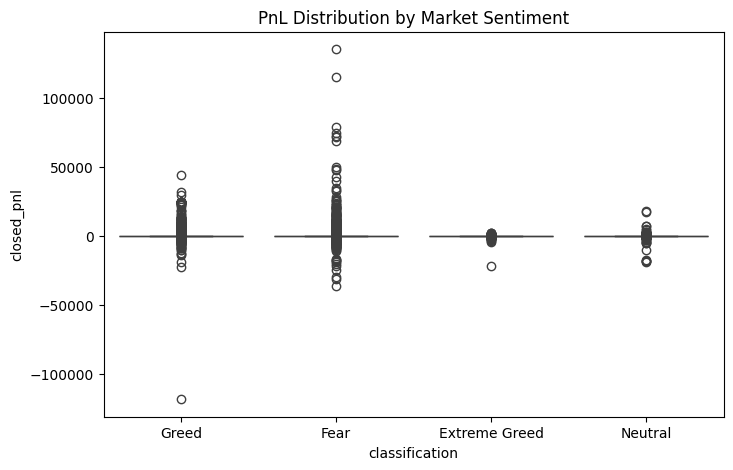

In [42]:
plt.figure(figsize=(8,5))
sns.boxplot(x='classification',y='closed_pnl',data=data)
plt.title("PnL Distribution by Market Sentiment")
plt.savefig("pnl_distribution_by_sentiment.png")
plt.show()

In [43]:
daily_pnl=data.groupby(['date','classification'])['closed_pnl'].sum().reset_index()

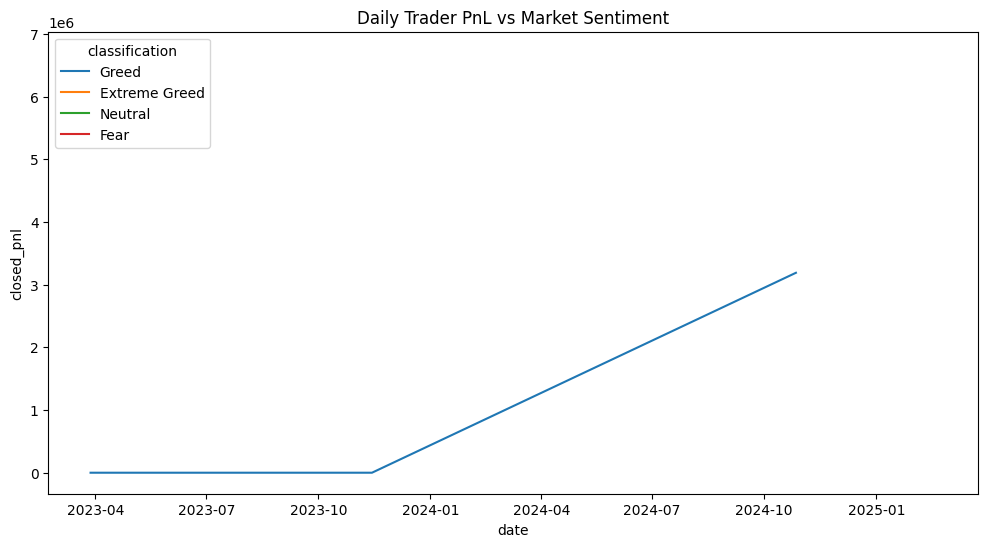

In [44]:
plt.figure(figsize=(12,6))
sns.lineplot(data=daily_pnl,x='date',y='closed_pnl',hue='classification')
plt.title("Daily Trader PnL vs Market Sentiment")
plt.savefig("daily_pnl_by_sentiment.png")
plt.show()

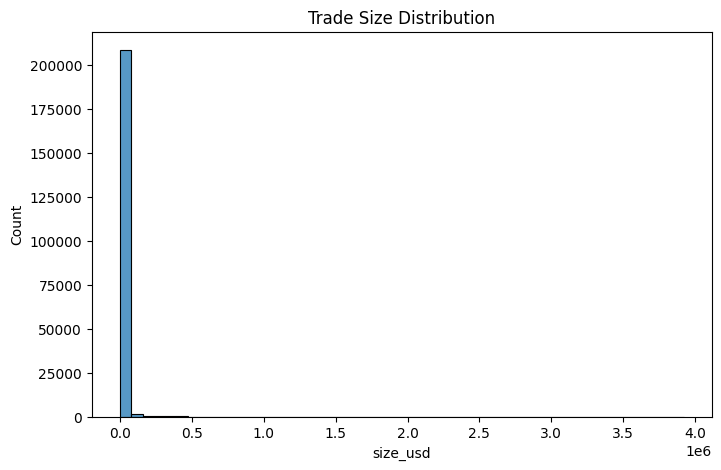

In [45]:
plt.figure(figsize=(8,5))
sns.histplot(data['size_usd'],bins=50)
plt.title("Trade Size Distribution")
plt.savefig("trade_size_distribution.png")
plt.show()

In [46]:
large_trades=data[data['size_usd']>data['size_usd'].quantile(0.90)]

In [47]:
print("\nLarge trades profit by sentiment")
print(large_trades.groupby('classification')['closed_pnl'].mean())


Large trades profit by sentiment
classification
Extreme Greed     58.343523
Fear             353.072725
Greed            607.954348
Neutral           47.914094
Name: closed_pnl, dtype: float64


In [48]:
top_traders=data.groupby('account')['closed_pnl'].sum().sort_values(ascending=False).head(10)

In [49]:
print("\nTop profitable traders")
print(top_traders)


Top profitable traders
account
0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23    2.143383e+06
0x083384f897ee0f19899168e3b1bec365f52a9012    1.600230e+06
0xbaaaf6571ab7d571043ff1e313a9609a10637864    9.401638e+05
0x513b8629fe877bb581bf244e326a047b249c4ff1    8.404226e+05
0xbee1707d6b44d4d52bfe19e41f8a828645437aab    8.360806e+05
0x4acb90e786d897ecffb614dc822eb231b4ffb9f4    6.777471e+05
0x72743ae2822edd658c0c50608fd7c5c501b2afbd    4.293556e+05
0x430f09841d65beb3f27765503d0f850b8bce7713    4.165419e+05
0x72c6a4624e1dffa724e6d00d64ceae698af892a0    4.030115e+05
0x75f7eeb85dc639d5e99c78f95393aa9a5f1170d4    3.790954e+05
Name: closed_pnl, dtype: float64


In [50]:
data.to_csv("merged_data.csv",index=False)
print("\nAnalysis completed.")


Analysis completed.
